# 04 — AI Models: Supervised & Unsupervised

**AI Equity Research Lab** — FGV EAESP (Aula 5)

This notebook:
1. **Trilha A (Supervised):** Walk-forward validation to predict outperformance vs Ibovespa
2. **Trilha B (Unsupervised):** K-Means clustering of tickers by financial profile
3. **Integration:** Merges all signals into a final master ranking

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)
%matplotlib inline

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\João Paulo\equity_research


---
## 1. Trilha A — Supervised Learning

### Why Walk-Forward Validation?

In financial time series, standard k-fold cross-validation introduces **data leakage** —
the model can inadvertently learn from future data that wouldn't be available at prediction time.

Walk-forward validation respects temporal ordering:
- **Fold 1:** Train on 2020, test on 2021
- **Fold 2:** Train on 2020–2021, test on 2022
- **Fold 3:** Train on 2020–2022, test on 2023

The model never sees future data during training. This mirrors a real investment process
where you can only use information available up to the decision date.

### Target Variable
- `label_outperform = 1` if the ticker's 12-month forward return exceeds the Ibovespa return
- This is a binary classification: *will this stock beat the market next year?*

In [2]:
from src.models.features import build_feature_matrix

feature_matrix = build_feature_matrix()
print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Columns: {list(feature_matrix.columns)}")
feature_matrix.head()

Feature matrix saved: C:\Users\João Paulo\equity_research\data\processed\feature_matrix.parquet  shape=(50, 23)
Feature matrix shape: (50, 23)
Columns: ['ticker', 'sector', 'year', 'net_margin', 'roe', 'roa', 'ebit_margin', 'debt_to_equity', 'net_debt_to_ebit', 'current_ratio', 'cash_to_revenue', 'revenue_cagr', 'net_income_cagr', 'volatility_annualized', 'max_drawdown', 'momentum_6m', 'momentum_12m', 'beta_vs_ibovespa', 'selic_mean', 'ipca_mean', 'usdbrl_mean', 'forward_return_12m', 'label_outperform']


,ticker,sector,year,net_margin,roe,roa,ebit_margin,debt_to_equity,net_debt_to_ebit,current_ratio,...,volatility_annualized,max_drawdown,momentum_6m,momentum_12m,beta_vs_ibovespa,selic_mean,ipca_mean,usdbrl_mean,forward_return_12m,label_outperform
0,ABCB4,Bancos,2020,0.143,0.079,0.008,-0.082,NaN,NaN,NaN,...,NaN,-0.536,0.128,-0.217,0.905,0.011,0.370,5.243,0.088,1
1,BBAS3,Bancos,2020,0.135,0.104,0.008,0.117,NaN,NaN,NaN,...,NaN,-0.583,0.238,-0.250,1.237,0.011,0.370,5.243,-0.199,0
2,BBDC4,Bancos,2020,0.163,0.110,0.010,0.041,NaN,NaN,NaN,...,NaN,-0.527,0.338,-0.182,1.119,0.011,0.370,5.243,-0.187,0
3,CMIG4,Energia Elétrica,2020,0.114,0.164,0.053,0.187,0.859,2.835,1.595,...,NaN,-0.504,0.417,0.125,1.029,0.011,0.370,5.243,0.117,1
4,CPFE3,Energia Elétrica,2020,0.120,0.260,0.075,0.165,1.326,2.924,0.959,...,NaN,-0.401,0.123,-0.022,0.740,0.011,0.370,5.243,-0.060,1


### 1.1 Walk-Forward Validation Results

In [3]:
from src.models.supervised import walk_forward_validation, aggregate_metrics

metrics_df = walk_forward_validation()
metrics_df

Walk-forward years available: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,fold,train_years,test_year,model,n_train,n_test,accuracy,precision,recall,f1,roc_auc
0,1,[np.int64(2020)],2021,LogisticRegression,10,10,0.800,0.875,0.875,0.875,0.875
1,1,[np.int64(2020)],2021,RandomForest,10,10,0.700,0.857,0.750,0.800,0.812
2,1,[np.int64(2020)],2021,GradientBoosting,10,10,0.800,0.875,0.875,0.875,0.812
3,2,"[np.int64(2020), np.int64(2021)]",2022,LogisticRegression,20,10,0.700,0.700,1.000,0.824,0.524
4,2,"[np.int64(2020), np.int64(2021)]",2022,RandomForest,20,10,0.600,0.667,0.857,0.750,0.429
5,2,"[np.int64(2020), np.int64(2021)]",2022,GradientBoosting,20,10,0.600,0.667,0.857,0.750,0.429
6,3,"[np.int64(2020), np.int64(2021), np.int64(2022)]",2023,LogisticRegression,30,10,0.500,0.429,0.750,0.545,0.375
7,3,"[np.int64(2020), np.int64(2021), np.int64(2022)]",2023,RandomForest,30,10,0.400,0.400,1.000,0.571,0.333
8,3,"[np.int64(2020), np.int64(2021), np.int64(2022)]",2023,GradientBoosting,30,10,0.400,0.375,0.750,0.500,0.458


In [4]:
# Aggregated metrics per model (mean +/- std across folds)
agg = aggregate_metrics(metrics_df)
agg

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,GradientBoosting,0.600,0.200,0.639,0.251,0.827,0.068,0.708,0.191,0.566,0.213
1,LogisticRegression,0.667,0.153,0.668,0.225,0.875,0.125,0.748,0.178,0.591,0.257
2,RandomForest,0.567,0.153,0.641,0.230,0.869,0.125,0.707,0.120,0.525,0.253


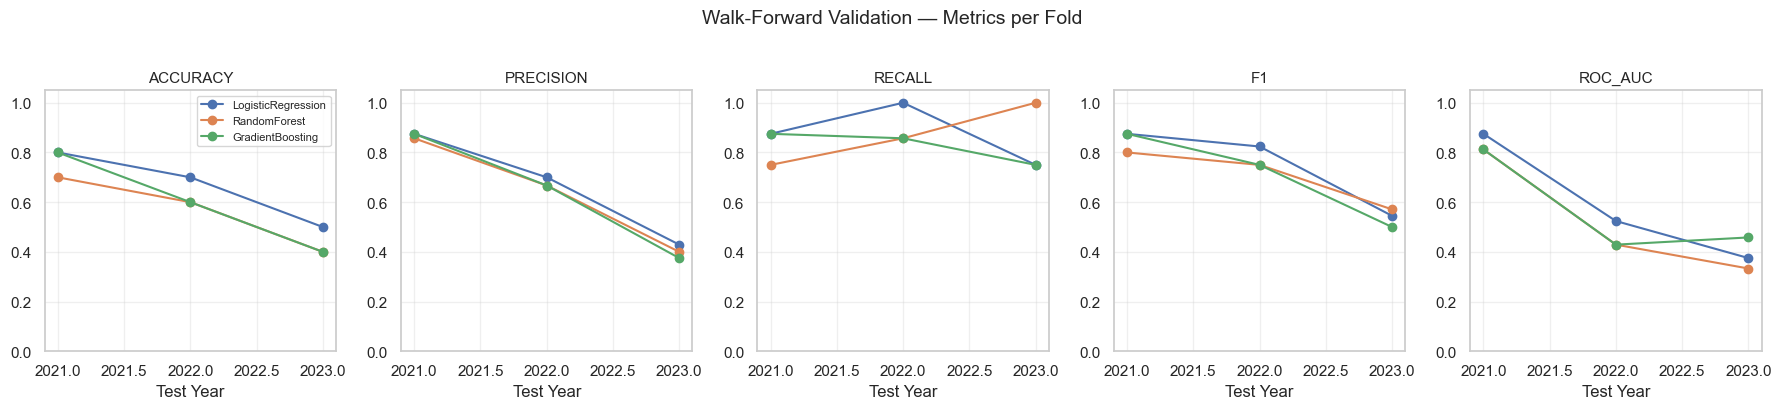

In [5]:
# Walk-forward performance comparison
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
models = metrics_df["model"].unique()

fig, axes = plt.subplots(1, len(metric_cols), figsize=(18, 4), sharey=False)

for ax, metric in zip(axes, metric_cols):
    for model in models:
        subset = metrics_df[metrics_df["model"] == model]
        ax.plot(subset["test_year"], subset[metric], marker="o", label=model)
    ax.set_title(metric.upper(), fontsize=11)
    ax.set_xlabel("Test Year")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8)
plt.suptitle("Walk-Forward Validation \u2014 Metrics per Fold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Select best model by mean roc_auc
best_row = agg.sort_values("roc_auc_mean", ascending=False).iloc[0]
best_model_name = best_row["model"]
print(f"Best model: {best_model_name}")
print(f"  Mean ROC AUC: {best_row['roc_auc_mean']:.3f} +/- {best_row['roc_auc_std']:.3f}")
print(f"  Mean F1:      {best_row['f1_mean']:.3f} +/- {best_row['f1_std']:.3f}")

Best model: LogisticRegression
  Mean ROC AUC: 0.591 +/- 0.257
  Mean F1:      0.748 +/- 0.178


### 1.2 Feature Importance

The best model is retrained on all labeled data (2020–2023) to extract feature importances.
These show which financial indicators most influence the outperformance prediction.

In [7]:
from src.models.supervised import extract_feature_importance

fi, model, scaler = extract_feature_importance(best_model_name=best_model_name)
fi

Feature importance saved: C:\Users\João Paulo\equity_research\data\processed\feature_importance.parquet


,feature,importance,rank
0,beta_vs_ibovespa,0.936,1
1,usdbrl_mean,0.734,2
2,momentum_12m,0.729,3
3,momentum_6m,0.562,4
4,cash_to_revenue,0.508,5
5,net_income_cagr,0.502,6
6,net_margin,0.382,7
7,selic_mean,0.331,8
8,roa,0.235,9
9,volatility_annualized,0.231,10


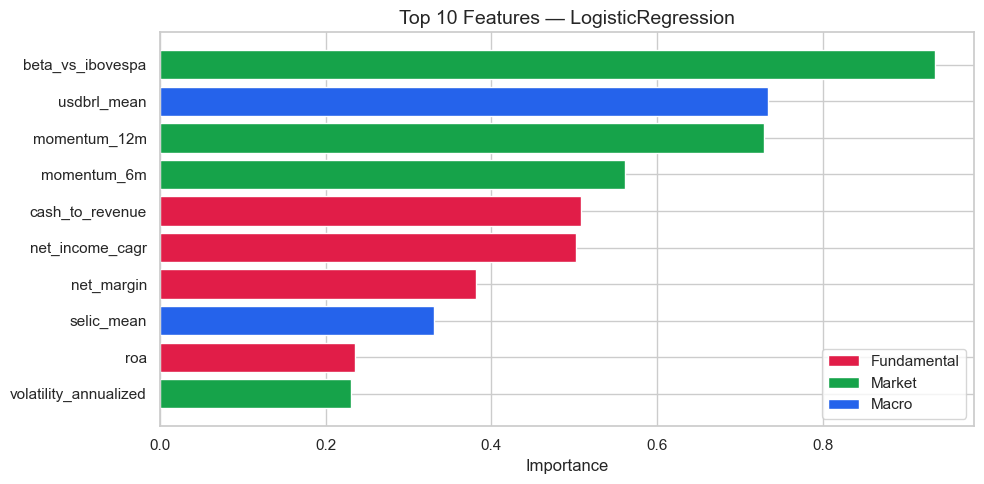

In [8]:
# Top 10 feature importance — horizontal bar chart
top10 = fi.head(10).sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2563eb" if "selic" in f or "ipca" in f or "usdbrl" in f
          else "#16a34a" if "momentum" in f or "volatility" in f or "drawdown" in f or "beta" in f
          else "#e11d48" for f in top10["feature"]]
ax.barh(top10["feature"], top10["importance"], color=colors, edgecolor="white")
ax.set_xlabel("Importance")
ax.set_title(f"Top 10 Features \u2014 {best_model_name}", fontsize=14)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e11d48", label="Fundamental"),
    Patch(facecolor="#16a34a", label="Market"),
    Patch(facecolor="#2563eb", label="Macro"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

### 1.3 Predictions for 2024

The best model is trained on **all labeled data (2020–2023)** and used to predict
which tickers will outperform the Ibovespa in 2024. No 2024 labels are used in training.

In [9]:
from src.models.supervised import predict_2024

preds = predict_2024()
preds

2024 predictions saved: C:\Users\João Paulo\equity_research\data\processed\supervised_predictions_2024.parquet


,ticker,sector,label_outperform_pred,outperform_probability
0,CPFE3,Energia Elétrica,1,0.994
1,EGIE3,Energia Elétrica,1,0.994
2,ITUB4,Bancos,1,0.985
3,TAEE11,Energia Elétrica,1,0.910
4,BBAS3,Bancos,1,0.534
5,CMIG4,Energia Elétrica,1,0.520
6,ABCB4,Bancos,0,0.459
7,SANB11,Bancos,0,0.389
8,EQTL3,Energia Elétrica,0,0.372
9,BBDC4,Bancos,0,0.025


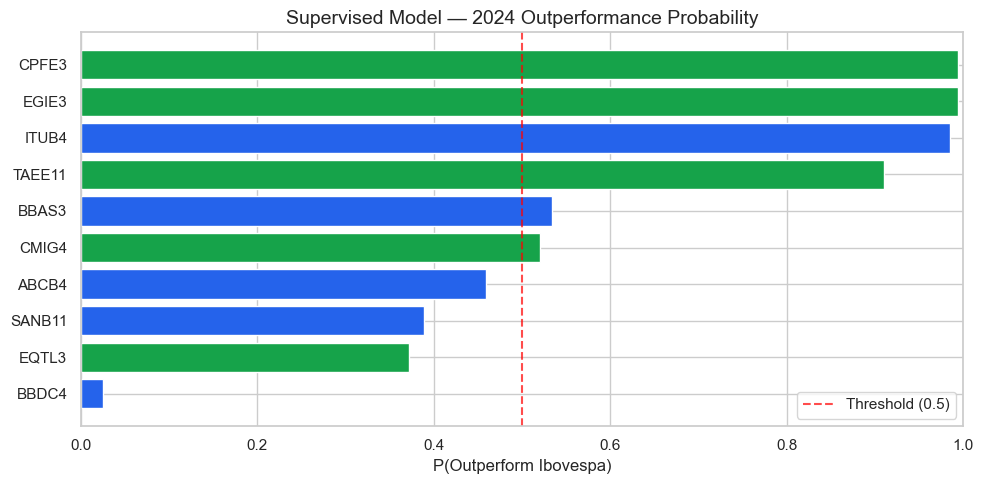

In [10]:
# Outperform probability bar chart
fig, ax = plt.subplots(figsize=(10, 5))
preds_sorted = preds.sort_values("outperform_probability")
colors = ["#2563eb" if s == "Bancos" else "#16a34a" for s in preds_sorted["sector"]]
ax.barh(preds_sorted["ticker"], preds_sorted["outperform_probability"],
        color=colors, edgecolor="white")
ax.axvline(0.5, color="red", linestyle="--", alpha=0.7, label="Threshold (0.5)")
ax.set_xlabel("P(Outperform Ibovespa)")
ax.set_title("Supervised Model \u2014 2024 Outperformance Probability", fontsize=14)
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Trilha B \u2014 Unsupervised Clustering

### What the Clusters Mean

K-Means groups the 10 tickers into clusters based on their **2024 financial KPIs** alone \u2014
no labels, no target variable. The algorithm finds tickers with similar financial profiles.

After clustering, we label each group heuristically:
- **Quality:** High ROE, high margins \u2192 stable, profitable companies
- **Growth:** High revenue/income growth, positive momentum \u2192 expanding companies
- **Risk:** High volatility, large drawdowns \u2192 more volatile/leveraged profiles

This is a **complementary signal** \u2014 it tells us *what kind of company* each ticker is,
not whether it will outperform.

In [11]:
from src.models.unsupervised import run_unsupervised_pipeline

unsup_results = run_unsupervised_pipeline()

TRILHA B — Unsupervised Clustering Pipeline
2024 KPIs: 10 tickers



Silhouette scores: {2: 0.24, 3: 0.294, 4: 0.256, 5: 0.191, 6: 0.139}
Best k = 3
PCA explained variance: [0.393 0.297]

--- Cluster Profiles ---
            net_margin   roe   roa  ebit_margin  debt_to_equity  net_debt_to_ebit  current_ratio  cash_to_revenue  revenue_cagr  net_income_cagr  volatility_annualized  max_drawdown  momentum_6m  momentum_12m cluster_label
cluster_id                                                                                                                                                                                                                    
0                0.100 0.141 0.023        0.147           1.464             3.053          1.051            0.295         0.229            0.118                  0.223        -0.209       -0.063        -0.160          Risk
1                0.420 0.297 0.084        0.727           1.669             2.862          1.109            0.277        -0.006            0.022                  0.160        -0.160     

### 2.1 Optimal Number of Clusters

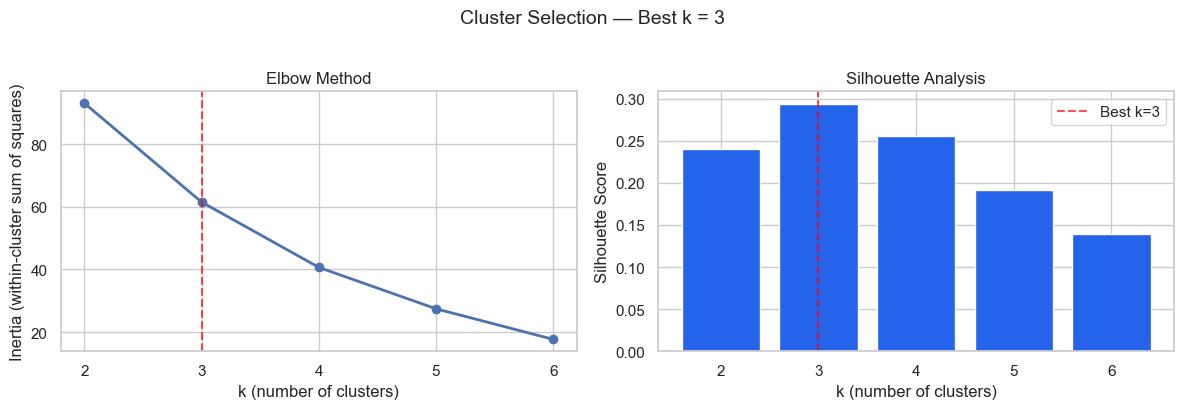

In [12]:
k_range = unsup_results["k_range"]
inertias = unsup_results["inertias"]
silhouettes = unsup_results["silhouettes"]
best_k = unsup_results["best_k"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Elbow
ax1.plot(k_range, inertias, "bo-", linewidth=2)
ax1.axvline(best_k, color="red", linestyle="--", alpha=0.7)
ax1.set_xlabel("k (number of clusters)")
ax1.set_ylabel("Inertia (within-cluster sum of squares)")
ax1.set_title("Elbow Method")
ax1.set_xticks(k_range)

# Silhouette
ax2.bar(k_range, silhouettes, color="#2563eb", edgecolor="white")
ax2.axvline(best_k, color="red", linestyle="--", alpha=0.7, label=f"Best k={best_k}")
ax2.set_xlabel("k (number of clusters)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.set_xticks(k_range)
ax2.legend()

plt.suptitle(f"Cluster Selection \u2014 Best k = {best_k}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 PCA 2D Scatter \u2014 Ticker Clusters

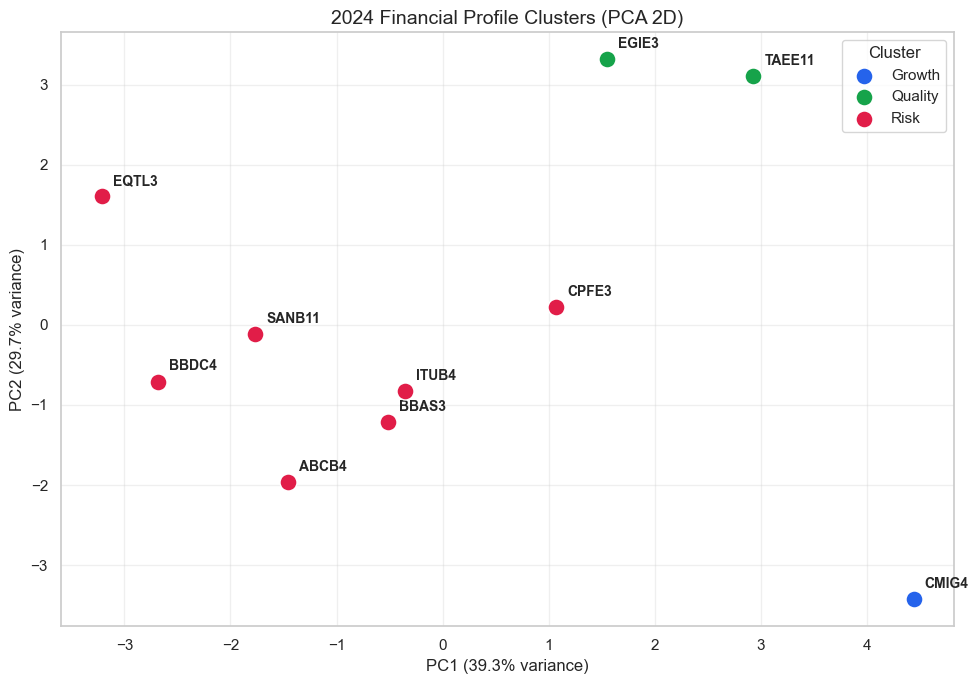

In [13]:
clusters = pd.read_parquet(PROCESSED_DIR / "clusters_2024.parquet")

fig, ax = plt.subplots(figsize=(10, 7))
cluster_colors = {"Quality": "#16a34a", "Growth": "#2563eb", "Risk": "#e11d48"}

for label, grp in clusters.groupby("cluster_label"):
    ax.scatter(grp["pca_x"], grp["pca_y"], s=150, label=label,
               color=cluster_colors.get(label, "#888"), edgecolors="white", zorder=5)
    for _, row in grp.iterrows():
        ax.annotate(row["ticker"], (row["pca_x"], row["pca_y"]),
                     textcoords="offset points", xytext=(8, 8),
                     fontsize=10, fontweight="bold")

ax.set_xlabel(f"PC1 ({unsup_results['pca'].explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({unsup_results['pca'].explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("2024 Financial Profile Clusters (PCA 2D)", fontsize=14)
ax.legend(title="Cluster", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Cluster Profile Heatmap

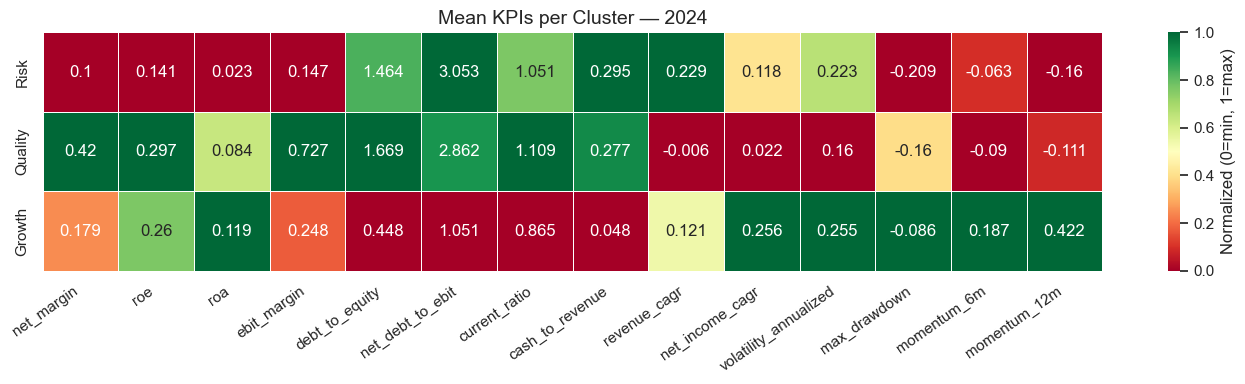

In [14]:
profile = unsup_results["profile"].drop(columns=["cluster_label"], errors="ignore")

fig, ax = plt.subplots(figsize=(14, 4))

# Normalize each column for color mapping
profile_norm = profile.copy()
for col in profile_norm.columns:
    cmin, cmax = profile_norm[col].min(), profile_norm[col].max()
    if cmax != cmin:
        profile_norm[col] = (profile_norm[col] - cmin) / (cmax - cmin)
    else:
        profile_norm[col] = 0.5

# Map cluster IDs to labels
cluster_labels = clusters.drop_duplicates("cluster_id").set_index("cluster_id")["cluster_label"]
ylabels = [cluster_labels.get(i, f"Cluster {i}") for i in profile.index]

sns.heatmap(profile_norm.values, annot=profile.round(3).values, fmt="",
            xticklabels=profile.columns, yticklabels=ylabels,
            cmap="RdYlGn", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Normalized (0=min, 1=max)"})
ax.set_title("Mean KPIs per Cluster \u2014 2024", fontsize=14)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

---
## 3. Integration \u2014 All Signals Combined

The final table merges three complementary views:
1. **Master Score** (Aulas 2\u20134): Fundamental + NLP sentiment ranking
2. **Supervised Prediction** (Trilha A): Probability of outperforming Ibovespa
3. **Unsupervised Cluster** (Trilha B): Financial profile category

Together, these provide a multi-dimensional investment signal for each ticker.

In [15]:
# Load all components
master = pd.read_parquet(PROCESSED_DIR / "master_scores_2024.parquet")
preds = pd.read_parquet(PROCESSED_DIR / "supervised_predictions_2024.parquet")
clusters = pd.read_parquet(PROCESSED_DIR / "clusters_2024.parquet")

# Merge
final = master.merge(
    preds[["ticker", "outperform_probability", "label_outperform_pred"]],
    on="ticker", how="left"
)
final = final.merge(
    clusters[["ticker", "cluster_label"]],
    on="ticker", how="left"
)

# Save
final.to_parquet(PROCESSED_DIR / "master_scores_final.parquet", index=False)
print(f"Saved: master_scores_final.parquet  shape={final.shape}")

Saved: master_scores_final.parquet  shape=(10, 23)


In [16]:
# Final integrated view
display_cols = [
    "ticker", "sector", "final_rank", "final_score",
    "outperform_probability", "label_outperform_pred", "cluster_label"
]
final_display = final[display_cols].sort_values("final_rank")
final_display

,ticker,sector,final_rank,final_score,outperform_probability,label_outperform_pred,cluster_label
0,CMIG4,Energia Elétrica,1,69.752,0.520,1,Growth
1,ITUB4,Bancos,2,69.667,0.985,1,Risk
2,EGIE3,Energia Elétrica,3,69.557,0.994,1,Quality
3,CPFE3,Energia Elétrica,4,68.868,0.994,1,Risk
4,ABCB4,Bancos,5,65.031,0.459,0,Risk
5,TAEE11,Energia Elétrica,6,61.662,0.910,1,Quality
6,BBAS3,Bancos,7,56.869,0.534,1,Risk
7,BBDC4,Bancos,8,51.690,0.025,0,Risk
8,EQTL3,Energia Elétrica,9,39.611,0.372,0,Risk
9,SANB11,Bancos,10,29.826,0.389,0,Risk


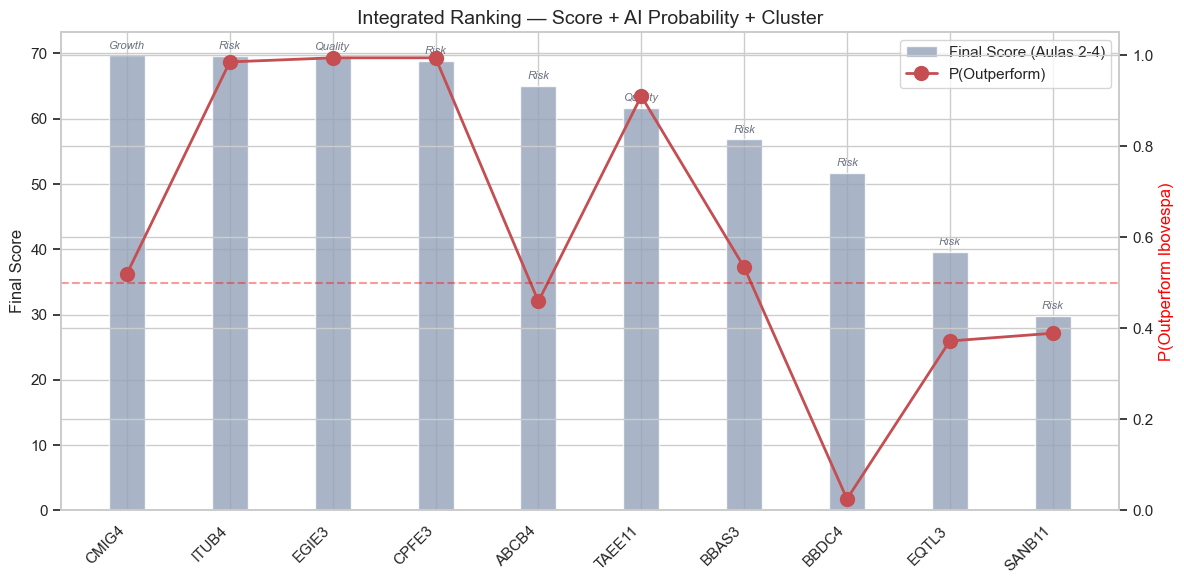

In [17]:
# Comprehensive signal chart
fig, ax = plt.subplots(figsize=(12, 6))
final_sorted = final.sort_values("final_rank")

x = range(len(final_sorted))
width = 0.35

# Bars: final score (left axis)
bars = ax.bar(x, final_sorted["final_score"], width, color="#94a3b8",
              edgecolor="white", label="Final Score (Aulas 2-4)", alpha=0.8)

ax2 = ax.twinx()
# Line: outperform probability (right axis)
ax2.plot(list(x), final_sorted["outperform_probability"].values,
         "ro-", markersize=10, linewidth=2, label="P(Outperform)")
ax2.axhline(0.5, color="red", linestyle="--", alpha=0.4)
ax2.set_ylabel("P(Outperform Ibovespa)", color="red")
ax2.set_ylim(0, 1.05)

# Cluster label annotations
for i, (_, row) in enumerate(final_sorted.iterrows()):
    ax.text(i, row["final_score"] + 1, row.get("cluster_label", ""),
            ha="center", fontsize=8, style="italic", color="#6b7280")

ax.set_xticks(list(x))
ax.set_xticklabels(final_sorted["ticker"], rotation=45, ha="right")
ax.set_ylabel("Final Score")
ax.set_title("Integrated Ranking \u2014 Score + AI Probability + Cluster", fontsize=14)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

### Data Quality Check

In [18]:
tables = {
    "feature_matrix": pd.read_parquet(PROCESSED_DIR / "feature_matrix.parquet"),
    "feature_importance": pd.read_parquet(PROCESSED_DIR / "feature_importance.parquet"),
    "supervised_predictions_2024": pd.read_parquet(PROCESSED_DIR / "supervised_predictions_2024.parquet"),
    "clusters_2024": pd.read_parquet(PROCESSED_DIR / "clusters_2024.parquet"),
    "master_scores_final": pd.read_parquet(PROCESSED_DIR / "master_scores_final.parquet"),
}

print("=" * 60)
print("DATA QUALITY SUMMARY \u2014 AI Models Module")
print("=" * 60)
for name, df in tables.items():
    print(f"\n{name}")
    print(f"  Shape: {df.shape[0]} rows x {df.shape[1]} cols")
    numeric_cols = df.select_dtypes(include='number')
    if not numeric_cols.empty:
        missing = numeric_cols.isna().sum()
        if missing.sum() == 0:
            print("  Missing numeric values: NONE")
        else:
            for col, n in missing.items():
                if n > 0:
                    print(f"  {col}: {n} NaN")

DATA QUALITY SUMMARY — AI Models Module

feature_matrix
  Shape: 50 rows x 23 cols
  net_margin: 6 NaN
  roe: 6 NaN
  roa: 6 NaN
  ebit_margin: 1 NaN
  debt_to_equity: 25 NaN
  net_debt_to_ebit: 25 NaN
  current_ratio: 25 NaN
  cash_to_revenue: 1 NaN
  net_income_cagr: 5 NaN
  volatility_annualized: 10 NaN

feature_importance
  Shape: 18 rows x 3 cols
  Missing numeric values: NONE

supervised_predictions_2024
  Shape: 10 rows x 4 cols
  Missing numeric values: NONE

clusters_2024
  Shape: 10 rows x 6 cols
  Missing numeric values: NONE

master_scores_final
  Shape: 10 rows x 23 cols
  roe_score: 2 NaN
  net_margin_score: 2 NaN
  net_income_cagr_score: 1 NaN
  debt_to_equity_score: 5 NaN
